# Subscription Churn and Cohort Retention

**Author: Tajamul Khan**

When do subscription cohorts lose customers?

Original synthetic teaching data. All outputs below are calculated by executing these cells. This is an analytical portfolio case study, not a real client engagement.

## Situation and task

A subscription team wants to distinguish early onboarding losses from later attrition.

Measure fully observed six-month retention and churn by plan.

## Data contract and KPI definitions

One row per subscriber; age zero is signup, first_inactive_month is the first month without activity. Month 6 retention = subscribers active at age 6 / original cohort size. Churn through month 6 is its complement; this is not monthly churn.

See `data/README.md` for field types, source and seed.

In [1]:
from pathlib import Path
import json, sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
BASE = Path.cwd()
assert (BASE/'data/raw.csv').exists(), 'Run from this project directory'
OUT = BASE/'outputs'
OUT.mkdir(exist_ok=True)
pd.set_option('display.max_columns', 20)
plt.rcParams.update({'figure.dpi':120, 'axes.spines.top':False, 'axes.spines.right':False})
df = pd.read_csv(BASE/'data/raw.csv')
if 'date' in df:
    df['date'] = pd.to_datetime(df['date'])
print('Raw shape:',df.shape)
display(df.head())


Raw shape: (2200, 4)


,customer_id,date,plan,first_inactive_month
0,1,2025-03-01,Basic,6
1,2,2025-05-01,Basic,1
2,3,2025-06-01,Pro,4
3,4,2025-05-01,Basic,7
4,5,2025-01-01,Pro,13


## Validate the source

Inspect missingness and grain before computing metrics. Missing outcomes are not automatically zeros.

In [2]:
audit=pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum(),'unique_values':df.nunique()})
display(audit)
print('Exact duplicate rows:',df.duplicated().sum())
audit.to_csv(OUT/'data_quality.csv')


Exact duplicate rows: 0


,dtype,missing,unique_values
customer_id,int64,0,2200
date,datetime64[ns],0,6
plan,object,0,2
first_inactive_month,int64,0,13


## Action: analysis

Construct monthly activity from signup and first inactive month, preserve cohort denominators and compare like-aged cohorts.

In [3]:
assert df.customer_id.is_unique and df.first_inactive_month.ge(1).all()
df['cohort']=df.date.dt.to_period('M').astype(str)
df['active_month6']=(df.first_inactive_month>6).astype(int)
summary=df.groupby('plan').agg(customers=('customer_id','size'),retained6=('active_month6','sum'))
summary['retention6_pct']=100*summary.retained6/summary.customers
cohort=pd.DataFrame({m:df.assign(active=df.first_inactive_month>m).groupby('cohort').active.mean() for m in range(7)})
cohort.to_csv(OUT/'cohort_retention.csv')
metrics={'Customers':len(df),'Month 6 retention (%)':100*df.active_month6.mean(),'Month 6 churn (%)':100*(1-df.active_month6.mean())}
chart=summary.retention6_pct; ylabel='Month 6 retention (%)'

## Deep dive: Retention across customer age

The heatmap compares each cohort at the same age. Month zero is 100% by construction. The fixed dataset has complete six-month follow-up.

Basic has lower six-month retention (43.04%). Compare onboarding and customer mix; the plan comparison is not randomized.
Out[4]: 122


,0,1,2,3,4,5,6
cohort,,,,,,,
2025-01,100.0,89.3,81.2,74.1,68.2,61.3,56.1
2025-02,100.0,88.7,77.7,69.0,62.8,54.2,47.9
2025-03,100.0,87.7,78.7,70.2,62.0,56.0,48.6
2025-04,100.0,87.5,77.7,70.5,61.6,54.3,49.0
2025-05,100.0,89.9,83.6,76.2,67.9,62.5,55.1
2025-06,100.0,90.1,83.6,75.4,68.0,61.2,55.2


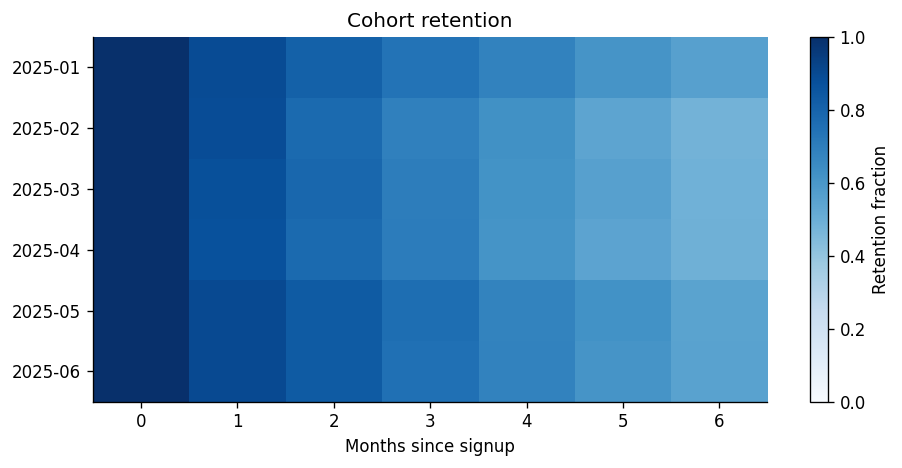

In [4]:

detail=cohort.copy();display((detail*100).round(1))
fig,ax=plt.subplots(figsize=(8,4));im=ax.imshow(detail,aspect='auto',vmin=0,vmax=1,cmap='Blues');ax.set_yticks(range(len(detail)),detail.index);ax.set_xticks(range(7),range(7));ax.set_xlabel('Months since signup');ax.set_title('Cohort retention');fig.colorbar(im,ax=ax,label='Retention fraction');fig.tight_layout();fig.savefig(OUT/'detail.png');plt.show()
weakest=summary.retention6_pct.idxmin()
recommendation=f'{weakest} has lower six-month retention ({summary.loc[weakest,"retention6_pct"]:.2f}%). Compare onboarding and customer mix; the plan comparison is not randomized.'

detail.to_csv(OUT/'detail.csv')
print(recommendation)
(OUT/'recommendation.txt').write_text(recommendation+'\n')


## Results: calculated evidence

These describe only the included synthetic dataset. They do not measure deployed impact.

In [5]:
display(summary.round(4))
display(pd.Series(metrics,name='value').to_frame())
summary.to_csv(OUT/'summary.csv')
(OUT/'metrics.json').write_text(json.dumps({k:float(v) for k,v in metrics.items()},indent=2))
df.to_csv(OUT/'analysis_ready.csv',index=False)
assert all(np.isfinite(float(v)) for v in metrics.values()), 'Invalid KPI'


,customers,retained6,retention6_pct
plan,,,
Basic,1106,476,43.0380
Pro,1094,671,61.3346


,value
Customers,2200.000000
Month 6 retention (%),52.136364
Month 6 churn (%),47.863636


## SQL cross-check

Load validated facts into SQLite and reconcile shared aggregates against Python.

In [6]:
with sqlite3.connect(':memory:') as conn:
    df.to_sql('facts',conn,index=False,if_exists='replace')
    sql_result=pd.read_sql_query((BASE/'analysis.sql').read_text(),conn)
display(sql_result)
sql_result.to_csv(OUT/'sql_results.csv',index=False)
# Reconcile at least one common aggregate by group, rather than trusting the SQL output.
key=sql_result.columns[0]
py=summary.reset_index()
common=[c for c in sql_result.columns[1:] if c in py.columns]
assert common, 'No comparable aggregate'
joined=sql_result.merge(py,on=key,suffixes=('_sql','_python'),validate='one_to_one')
assert len(joined)==len(summary)==len(sql_result)
for col in common:
    assert np.allclose(joined[col+'_sql'],joined[col+'_python'],rtol=1e-8,atol=1e-6), col
print('SQL / Python reconciliation passed:',common)


SQL / Python reconciliation passed: ['customers', 'retention6_pct']


,plan,customers,retention6_pct
0,Basic,1106,43.037975
1,Pro,1094,61.334552


## Visual interpretation

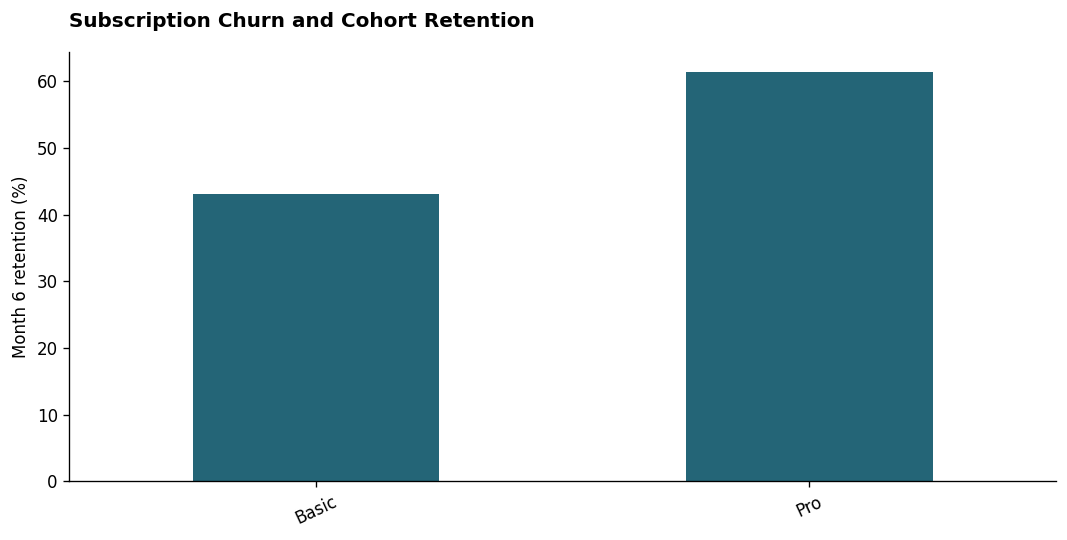

In [7]:
fig,ax=plt.subplots(figsize=(9,4.6))
chart.plot(kind='bar',ax=ax,color='#246577',rot=25)
ax.set_ylabel(ylabel)
ax.set_xlabel('')
ax.set_title('Subscription Churn and Cohort Retention',loc='left',fontweight='bold',pad=15)
fig.tight_layout()
fig.savefig(OUT/'overview.png',bbox_inches='tight')
plt.show()


## Offline dashboard

The KPI cards and chart are a fixed analysis snapshot. The row filter searches the summary table; it does not recompute the KPIs.

In [8]:
# Standalone dashboard: no remote JavaScript, server or account required.
import html, base64
cards=''.join('<article><span>'+html.escape(k)+'</span><strong>'+f'{v:,.4f}'+'</strong></article>' for k,v in metrics.items())
image=base64.b64encode((OUT/'overview.png').read_bytes()).decode()
table=summary.round(4).to_html(classes='data',border=0)
page='''<!doctype html><html lang="en"><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Subscription Churn and Cohort Retention</title>
<style>body{font:16px system-ui;margin:0;background:#f3f5f7;color:#172c3b}main{max-width:1100px;margin:auto;padding:36px}header{border-bottom:3px solid #246577;margin-bottom:24px}small{color:#51616c}.cards{display:flex;gap:14px;flex-wrap:wrap}article{background:white;padding:18px;border:1px solid #d7e0e5;flex:1;min-width:175px}strong{display:block;font-size:27px;margin-top:12px}img{max-width:100%;margin-top:24px}table{border-collapse:collapse;background:white;width:100%;font-size:14px}td,th{padding:12px;text-align:right;border-bottom:1px solid #d7e0e5}input{padding:12px;margin:20px 0;width:280px;max-width:90%}.scroll{overflow:auto}footer{margin-top:24px}</style>
<main><header><small>TAJAMUL KHAN · DATA ANALYST PORTFOLIO</small><h1>Subscription Churn and Cohort Retention</h1><p>When do subscription cohorts lose customers?</p><p><b>Synthetic teaching data · Fictional 2025 case study</b></p></header><section class="cards">'''+cards+'''</section><img alt="Analysis overview chart" src="data:image/png;base64,'''+image+'''"><h2>Explore summary groups</h2><label for="filter">Filter summary rows</label><br><input id="filter" placeholder="Type a group name"><div class="scroll">'''+table+'''</div><p>All cohorts have six months of follow-up by the snapshot. Churn is absorbing in this simulation; reactivations and competing events are excluded.</p><footer>Instagram @tajamul.codes · linkedin.com/in/tajamulkhann/</footer></main>
<script>document.getElementById('filter').addEventListener('input',function(){const q=this.value.toLowerCase();document.querySelectorAll('tbody tr').forEach(r=>r.hidden=!r.textContent.toLowerCase().includes(q))});</script></html>'''
detail_image=base64.b64encode((OUT/'detail.png').read_bytes()).decode()
page=page.replace('<h2>Explore summary groups</h2>','<h2>Analyst finding</h2><p>'+html.escape(recommendation)+'</p><img alt="Supporting analysis" src="data:image/png;base64,'+detail_image+'"><h2>Explore summary groups</h2>')
(OUT/'dashboard.html').write_text(page)
print('Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.')


Saved dashboard.html, overview.png, summary.csv, metrics.json, SQL results and analysis-ready data.


## Decision, limitations and next step

All cohorts have six months of follow-up by the snapshot. Churn is absorbing in this simulation; reactivations and competing events are excluded.

**Next step:** Extend to real event history with right censoring and reactivation states.

Use the result table to identify a priority for investigation. Avoid claiming that the suggested action has already delivered a business improvement.

## Career discussion

Explain the business question, data grain, denominator, validation, strongest finding and one limitation. Use the README STAR story only after reproducing and understanding this project.